# DSAA2011 Project Notebook

This notebook completes all mandatory tasks in the project PDF and includes an open-ended exploration section.

Dataset used: `data.csv` (Student Dropout dataset).

test

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, classification_report
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 6)
RANDOM_STATE = 42

## Task 1: Data Preprocessing

Requirements covered:
- Missing value handling
- Non-numeric value handling
- Feature standardization

In [7]:
# Load and clean raw data
df = pd.read_csv('data.csv', sep=';')
df.columns = df.columns.str.strip()

target_col = 'Target'
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print('Dataset shape:', df.shape)
print('Target classes:', y.value_counts().to_dict())

missing_count = df.isna().sum().sort_values(ascending=False)
print('\nTop missing-value columns:')
print(missing_count.head(10))

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print('\nNumeric feature count:', len(numeric_cols))
print('Categorical feature count:', len(categorical_cols))
if categorical_cols:
    print('Categorical columns:', categorical_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

X_processed = preprocessor.fit_transform(X)
X_dense = X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed

print('\nProcessed feature matrix shape:', X_dense.shape)

Dataset shape: (4424, 37)
Target classes: {'Graduate': 2209, 'Dropout': 1421, 'Enrolled': 794}

Top missing-value columns:
Marital status                    0
Application mode                  0
Application order                 0
Course                            0
Daytime/evening attendance        0
Previous qualification            0
Previous qualification (grade)    0
Nacionality                       0
Mother's qualification            0
Father's qualification            0
dtype: int64

Numeric feature count: 36
Categorical feature count: 0

Processed feature matrix shape: (4424, 36)


## Task 2: Data Visualization (t-SNE)

Requirements covered:
- 2D embedding with t-SNE
- Scatter plot with class labels
- Pattern discussion support

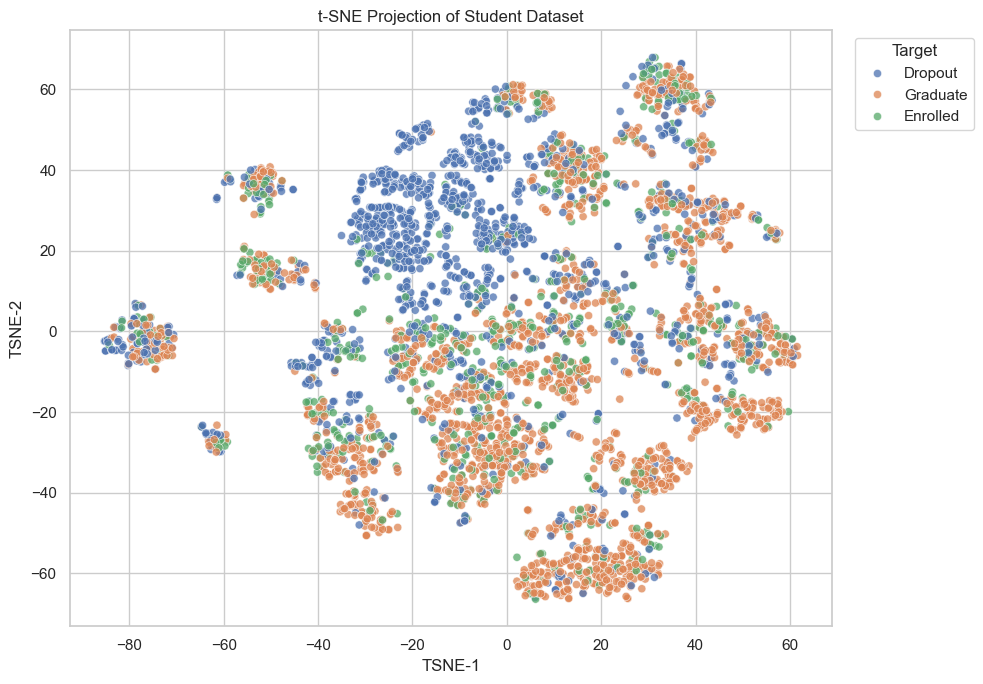

Observation: Look for regions where one class dominates, overlap areas, and outliers.


In [8]:
# t-SNE on preprocessed features
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto', perplexity=30)
X_tsne = tsne.fit_transform(X_dense)

tsne_df = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Target': y.values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='TSNE-1', y='TSNE-2', hue='Target', alpha=0.75, s=35)
plt.title('t-SNE Projection of Student Dataset')
plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Observation: Look for regions where one class dominates, overlap areas, and outliers.')

## Task 3: Clustering Analysis

Requirements covered:
- Two clustering algorithms (K-Means, Agglomerative)
- Multiple metrics
- Cluster visualizations
- Best-result comparison

,Algorithm,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI (vs Target),NMI (vs Target)
0,KMeans,0.214517,530.090466,2.003651,0.151671,0.158243
1,Agglomerative,0.165776,435.727473,2.005257,0.101316,0.117288


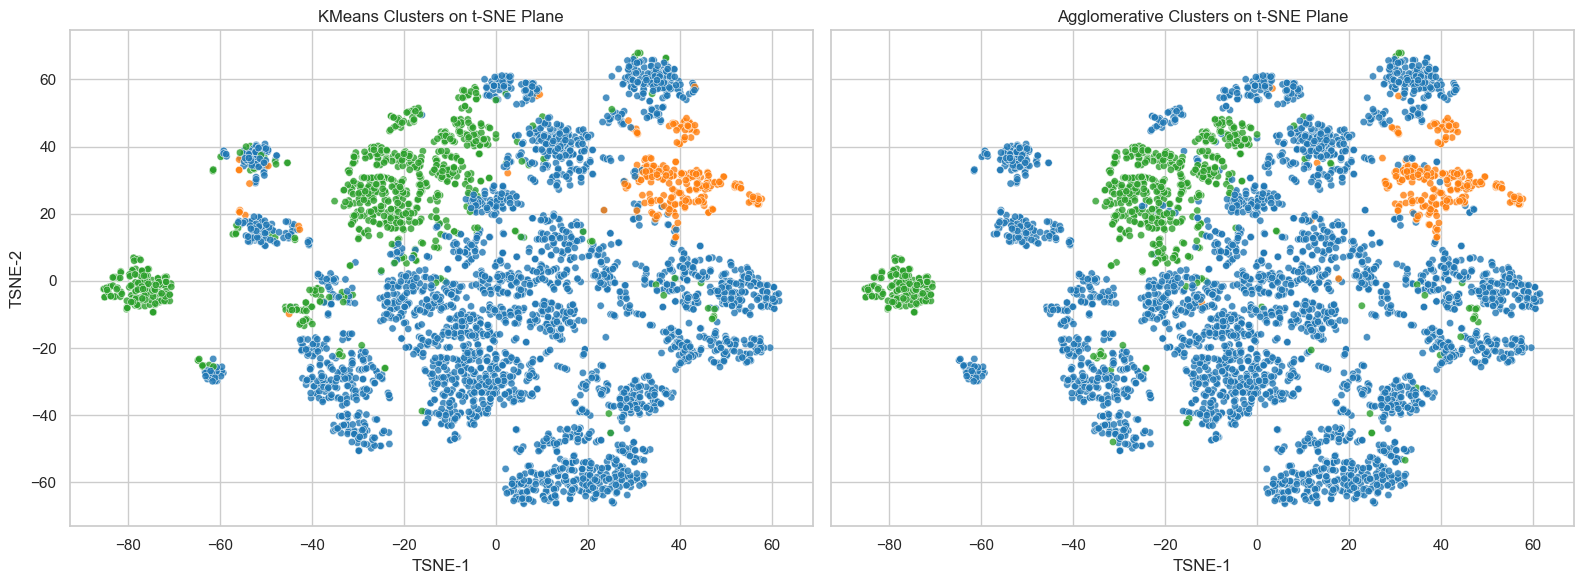

Best clustering by silhouette score: KMeans


In [9]:
# Encode target labels for external cluster-quality metrics
y_codes = pd.Categorical(y).codes
n_clusters = y.nunique()

cluster_models = {
    'KMeans': KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters)
}

cluster_results = []
cluster_labels = {}

for name, model in cluster_models.items():
    labels = model.fit_predict(X_dense)
    cluster_labels[name] = labels

    result = {
        'Algorithm': name,
        'Silhouette': silhouette_score(X_dense, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_dense, labels),
        'Davies-Bouldin': davies_bouldin_score(X_dense, labels),
        'ARI (vs Target)': adjusted_rand_score(y_codes, labels),
        'NMI (vs Target)': normalized_mutual_info_score(y_codes, labels),
    }
    cluster_results.append(result)

cluster_df = pd.DataFrame(cluster_results).sort_values(by='Silhouette', ascending=False)
display(cluster_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, cluster_labels.items()):
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette='tab10', s=28, alpha=0.8, ax=ax, legend=False)
    ax.set_title(f'{name} Clusters on t-SNE Plane')
    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
plt.tight_layout()
plt.show()

best_alg = cluster_df.iloc[0]['Algorithm']
print(f'Best clustering by silhouette score: {best_alg}')

## Task 4: Prediction (Training and Testing)

Requirements covered:
- Classification target: `Target`
- Two model classes: Logistic Regression, Decision Tree
- 70/30 train-test split
- Evaluation on train, test, and full dataset
- Confusion matrices and decision-boundary visualization

,Model,Split,Accuracy,Precision(macro),Recall(macro),F1(macro)
5,DecisionTree,All,0.904159,0.882316,0.891060,0.886288
4,DecisionTree,Test,0.680723,0.633726,0.636941,0.633106
3,DecisionTree,Train,1.000000,1.000000,1.000000,1.000000
2,LogisticRegression,All,0.773734,0.718607,0.680305,0.689573
1,LogisticRegression,Test,0.775602,0.722996,0.685988,0.696026
0,LogisticRegression,Train,0.772933,0.716566,0.677878,0.686705


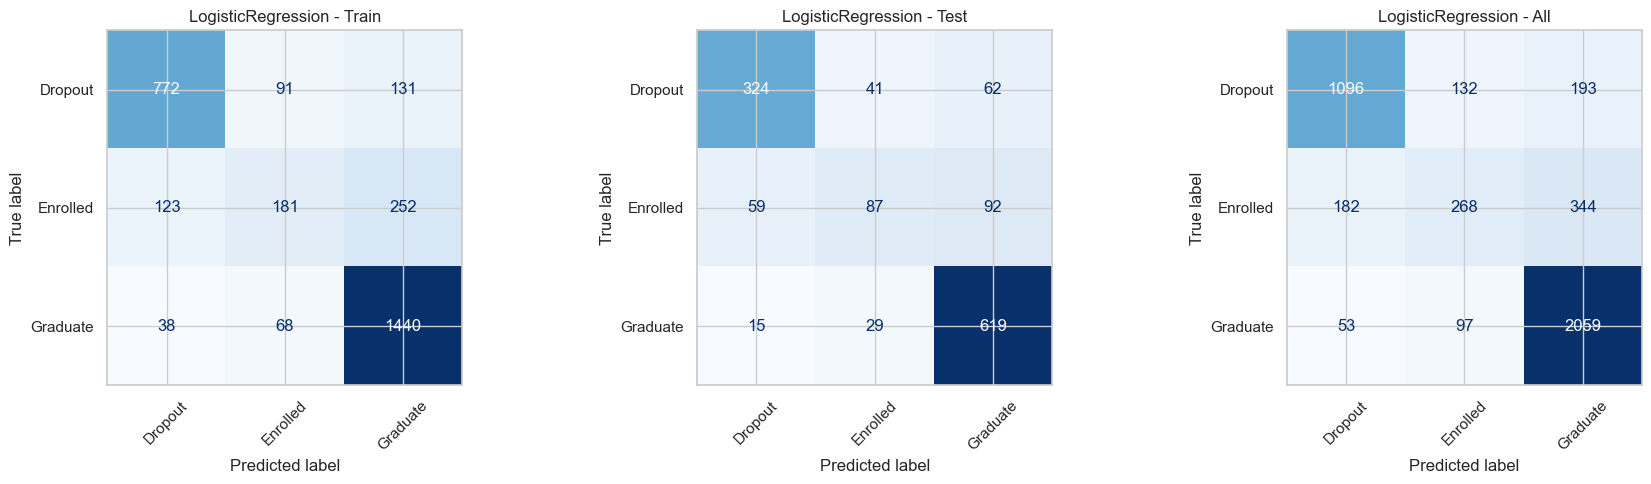

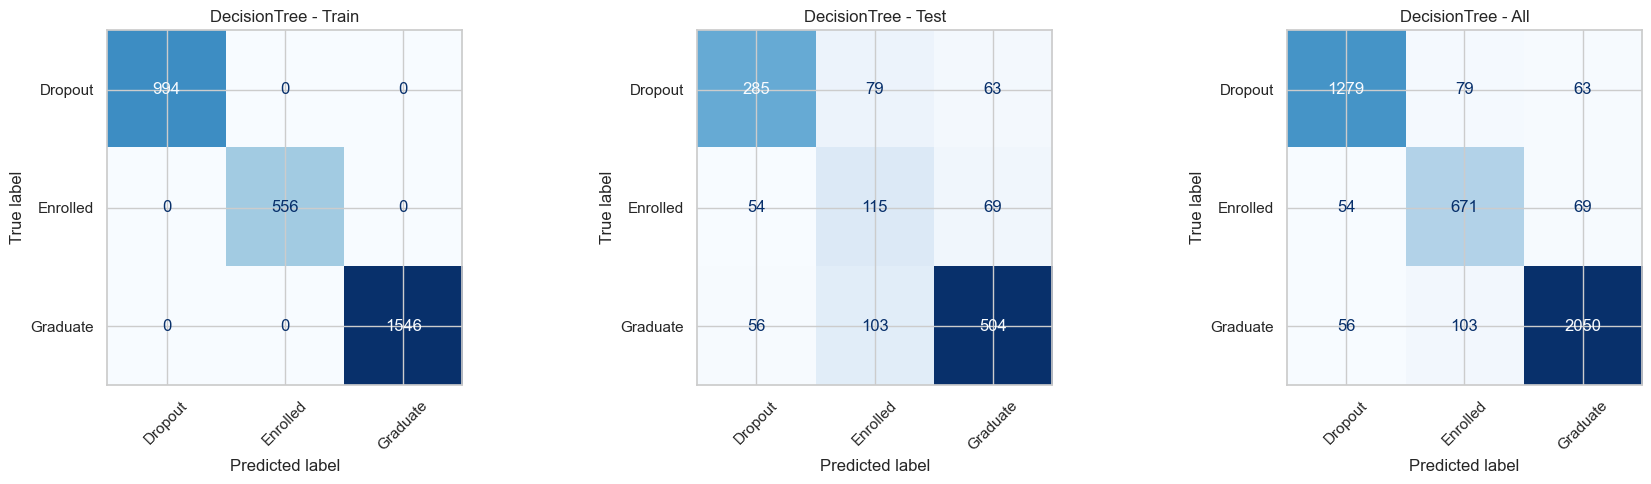

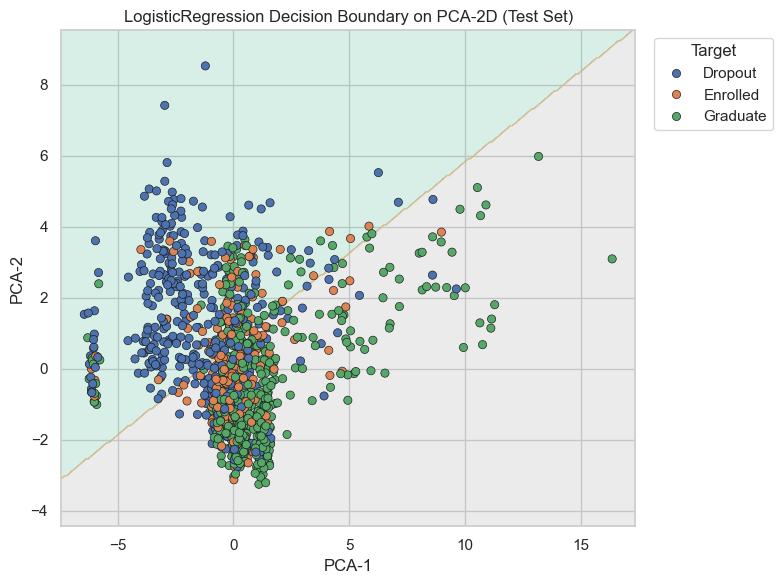

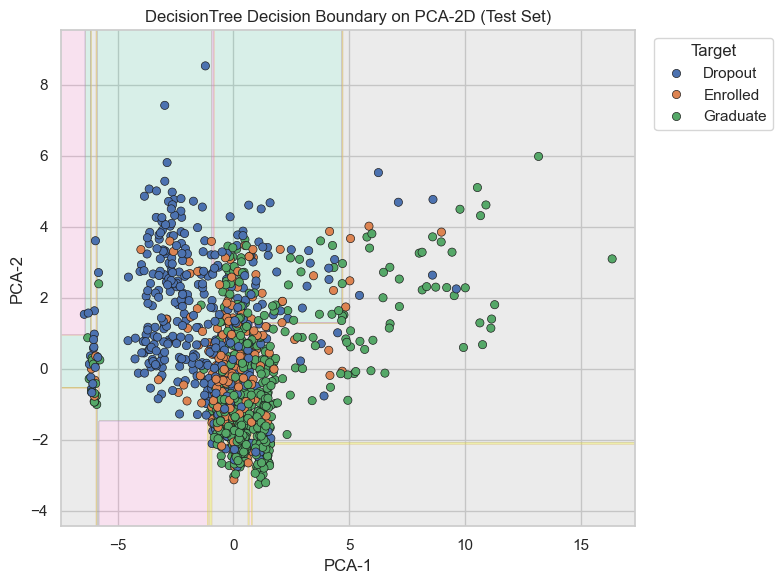

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=400, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}

fitted_models = {}
eval_rows = []

for name, base_model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', base_model)
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    for split_name, X_split, y_split in [
        ('Train', X_train, y_train),
        ('Test', X_test, y_test),
        ('All', X, y),
    ]:
        y_pred = pipe.predict(X_split)
        eval_rows.append({
            'Model': name,
            'Split': split_name,
            'Accuracy': accuracy_score(y_split, y_pred),
            'Precision(macro)': precision_score(y_split, y_pred, average='macro'),
            'Recall(macro)': recall_score(y_split, y_pred, average='macro'),
            'F1(macro)': f1_score(y_split, y_pred, average='macro'),
        })

eval_df = pd.DataFrame(eval_rows)
display(eval_df.sort_values(['Model', 'Split']))

# Confusion matrices for Train/Test/All for each model
for name, model in fitted_models.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (split_name, X_split, y_split) in zip(axes, [('Train', X_train, y_train), ('Test', X_test, y_test), ('All', X, y)]):
        ConfusionMatrixDisplay.from_predictions(y_split, model.predict(X_split), cmap='Blues', xticks_rotation=45, ax=ax, colorbar=False)
        ax.set_title(f'{name} - {split_name}')
    plt.tight_layout()
    plt.show()

# Decision boundary visualization on 2D PCA projection (for interpretability)
X_num = df.drop(columns=[target_col]).select_dtypes(include=['number'])
X_num = X_num.fillna(X_num.median(numeric_only=True))
X_num_scaled = StandardScaler().fit_transform(X_num)
X_pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_num_scaled)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_pca2, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

viz_models = {
    'LogisticRegression': LogisticRegression(max_iter=400, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6),
}

for name, m in viz_models.items():
    m.fit(X2_train, y2_train)
    x_min, x_max = X_pca2[:, 0].min() - 1, X_pca2[:, 0].max() + 1
    y_min, y_max = X_pca2[:, 1].min() - 1, X_pca2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    class_to_code = {cls: i for i, cls in enumerate(m.classes_)}
    Z_codes = np.vectorize(class_to_code.get)(Z)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z_codes, alpha=0.25, cmap='Set2')
    sns.scatterplot(x=X2_test[:, 0], y=X2_test[:, 1], hue=y2_test, s=35, edgecolor='k')
    plt.title(f'{name} Decision Boundary on PCA-2D (Test Set)')
    plt.xlabel('PCA-1')
    plt.ylabel('PCA-2')
    plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Task 5: Evaluation and Choice of Prediction Model

Requirements covered:
- Accuracy, precision, recall, F1-score
- ROC curve and AUC
- Validation-based improvement for each model
- Strength/weakness interpretation support

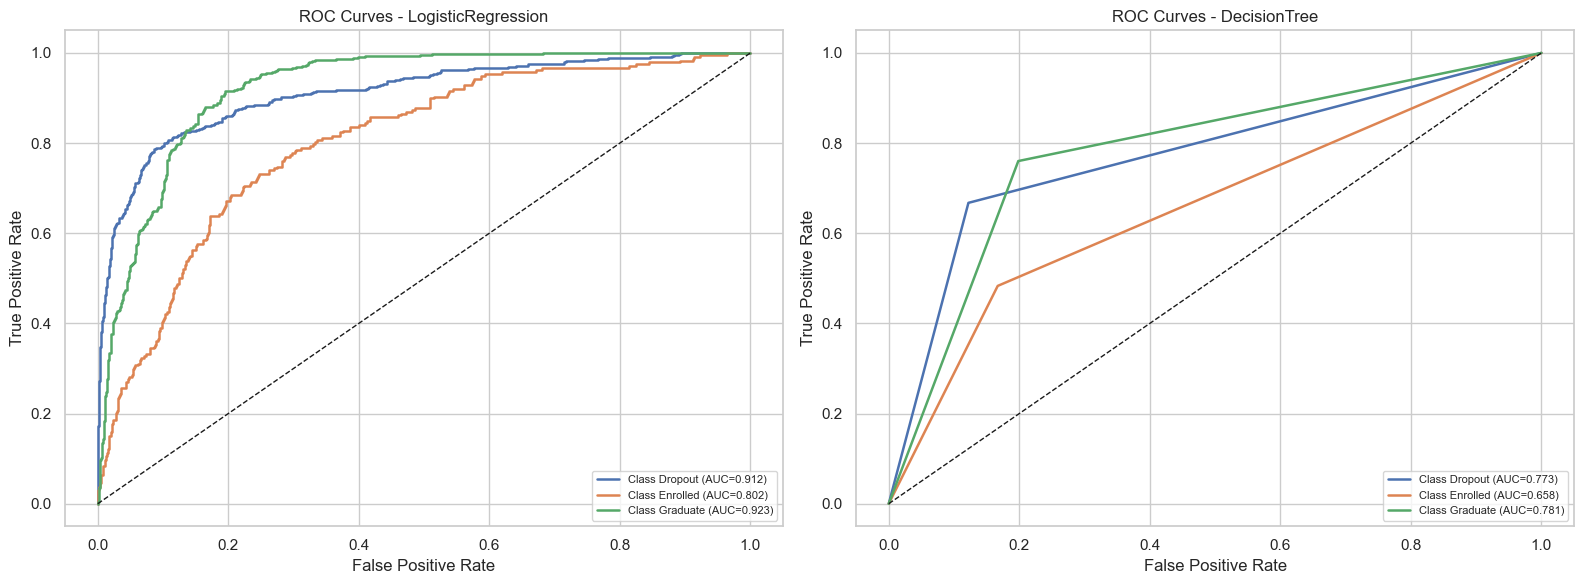

,Model,AUC (macro OVR)
0,LogisticRegression,0.879041
1,DecisionTree,0.737211


Best LogisticRegression params: {'model__C': 10.0, 'model__class_weight': 'balanced'}
Best DecisionTree params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_split': 2}


,Model,Accuracy (test),"Precision (macro, test)","Recall (macro, test)","F1 (macro, test)"
0,LogisticRegression_tuned,0.733434,0.705950,0.707298,0.695583
1,DecisionTree_tuned,0.671687,0.692257,0.674664,0.652591



LogisticRegression_tuned
              precision    recall  f1-score   support

     Dropout       0.84      0.68      0.75       427
    Enrolled       0.41      0.64      0.50       238
    Graduate       0.86      0.80      0.83       663

    accuracy                           0.73      1328
   macro avg       0.71      0.71      0.70      1328
weighted avg       0.78      0.73      0.75      1328


DecisionTree_tuned
              precision    recall  f1-score   support

     Dropout       0.88      0.63      0.73       427
    Enrolled       0.35      0.71      0.47       238
    Graduate       0.85      0.69      0.76       663

    accuracy                           0.67      1328
   macro avg       0.69      0.67      0.65      1328
weighted avg       0.77      0.67      0.70      1328



In [11]:
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
auc_summary = []

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_score = model.predict_proba(X_test)
    macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')
    auc_summary.append({'Model': name, 'AUC (macro OVR)': macro_auc})

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, lw=1.8, label=f'Class {cls} (AUC={auc(fpr, tpr):.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC Curves - {name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

display(pd.DataFrame(auc_summary))

# Validation-driven improvements (GridSearchCV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logi_grid = GridSearchCV(
    Pipeline([('preprocess', preprocessor), ('model', LogisticRegression(max_iter=600, random_state=RANDOM_STATE))]),
    param_grid={
        'model__C': [0.1, 1.0, 10.0],
        'model__class_weight': [None, 'balanced']
    },
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

tree_grid = GridSearchCV(
    Pipeline([('preprocess', preprocessor), ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    param_grid={
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 10, 20],
        'model__class_weight': [None, 'balanced']
    },
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

logi_grid.fit(X_train, y_train)
tree_grid.fit(X_train, y_train)

improved_models = {
    'LogisticRegression_tuned': logi_grid.best_estimator_,
    'DecisionTree_tuned': tree_grid.best_estimator_,
}

print('Best LogisticRegression params:', logi_grid.best_params_)
print('Best DecisionTree params:', tree_grid.best_params_)

comparison_rows = []
for name, model in improved_models.items():
    y_pred_test = model.predict(X_test)
    comparison_rows.append({
        'Model': name,
        'Accuracy (test)': accuracy_score(y_test, y_pred_test),
        'Precision (macro, test)': precision_score(y_test, y_pred_test, average='macro'),
        'Recall (macro, test)': recall_score(y_test, y_pred_test, average='macro'),
        'F1 (macro, test)': f1_score(y_test, y_pred_test, average='macro')
    })

display(pd.DataFrame(comparison_rows))

for name, model in improved_models.items():
    print('\n' + '=' * 60)
    print(name)
    print(classification_report(y_test, model.predict(X_test)))

## Open-ended Exploration

This section adds one more model class (Random Forest), performs cross-validation comparison, and inspects feature importance.

,Model,CV F1-macro mean,CV F1-macro std
0,LogisticRegression_tuned,0.698184,0.015667
2,RandomForest,0.686665,0.006116
1,DecisionTree_tuned,0.664400,0.013324


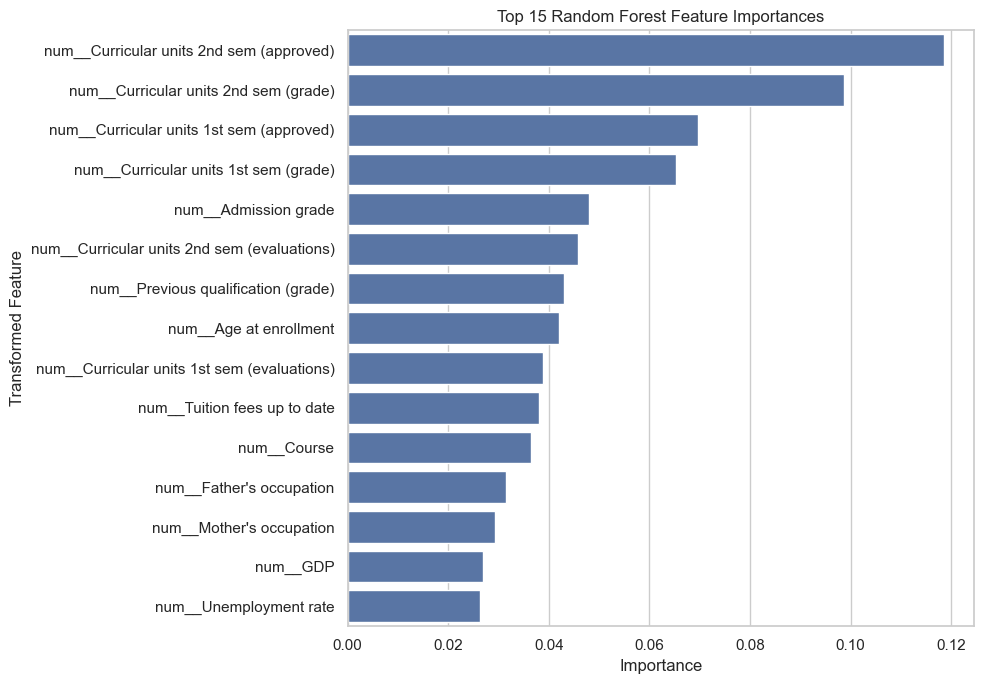

In [12]:
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300, class_weight='balanced_subsample'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_summary = []
for name, model in {
    'LogisticRegression_tuned': improved_models['LogisticRegression_tuned'],
    'DecisionTree_tuned': improved_models['DecisionTree_tuned'],
    'RandomForest': rf_pipe
}.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_summary.append({
        'Model': name,
        'CV F1-macro mean': scores.mean(),
        'CV F1-macro std': scores.std()
    })

cv_df = pd.DataFrame(cv_summary).sort_values('CV F1-macro mean', ascending=False)
display(cv_df)

# Fit random forest once and inspect top transformed feature importances
rf_pipe.fit(X_train, y_train)
rf_model = rf_pipe.named_steps['model']
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_imp.values, y=feat_imp.index, orient='h')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Transformed Feature')
plt.tight_layout()
plt.show()

## Final Discussion Notes (Write-up Helper)

Use the computed tables and plots above to write your 100-200 word model-performance discussion:
- Compare train/test/all metrics to identify possible overfitting.
- Use ROC/AUC and class-level reports to discuss strengths and weaknesses by class.
- Justify your final model choice using both predictive performance and robustness (CV variance).